In [189]:
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

In [190]:
df = pd.read_csv('../data/transformed_data.csv')
df.head()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,...,magType_mlg,magType_ms,magType_ms_20,magType_mw,magType_mwb,magType_mwc,magType_mwp,magType_mwr,magType_mww,magType_uk
0,-23.4332,-179.8984,547.033,5.5,63.0,39.0,5.976,1.13,8.66,7.704,...,False,False,False,False,False,False,False,False,True,False
1,7.2863,127.0595,11.854,5.5,58.0,53.0,1.485,1.40,5.21,4.721,...,False,False,False,False,False,False,False,False,True,False
2,7.3902,126.7221,35.000,6.4,118.0,30.0,1.178,1.17,7.94,1.842,...,False,False,False,False,False,False,False,False,True,False
3,-17.6276,168.2465,62.384,5.0,47.0,79.0,2.388,0.54,9.64,6.266,...,False,False,False,False,False,False,False,False,True,False
4,37.2523,74.6137,10.000,5.2,112.0,54.0,1.991,0.88,6.54,1.848,...,False,False,False,False,False,False,False,False,False,False


In [191]:
strategy = 'median'
imputer = SimpleImputer(strategy=strategy)
scaler = StandardScaler()

In [192]:
X = df.drop("mag", axis=1)
y = df["mag"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Model prédiction Magnitude

In [195]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [196]:
def display_train_test_metrics(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"MAE  : {mean_absolute_error(y_test, y_pred)}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred))}")
    print(f"R²   : {r2_score(y_test, y_pred)}")

In [197]:
def search_hyperparameters(max_depths, min_child_weights, n_estimators, learning_rates, X_train, y_train, X_test, y_test):
    for i in max_depths:
        for j in min_child_weights:
            for k in n_estimators:
                for l in learning_rates:
                    print(f'max_depth: {i}, min_child_weight: {j}, n_estimators: {k}, learning_rate: {l}')
                    xgb_model = xgb.XGBRegressor(max_depth=i, min_child_weight=j, n_estimators=k, learning_rate=l, random_state=42)
                    display_train_test_metrics(xgb_model, X_train, y_train, X_test, y_test)

In [198]:
# search_hyperparameters([3, 6, 9], [1, 5, 10], [100, 500, 1000], [0.3, 0.15, 0.05], X_train, y_train, X_test, y_test)

In [200]:
xgb_model = xgb.XGBRegressor(random_state=42)

In [201]:
xgb_model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

## Analyse


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

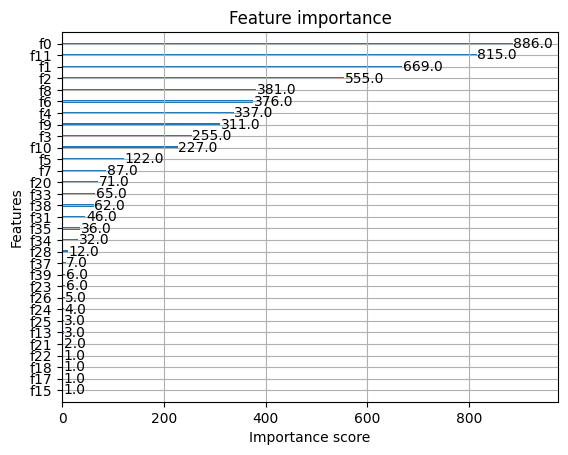

In [203]:
xgb.plot_importance(xgb_model)

In [204]:
y_pred = xgb_model.predict(X_test_scaled)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  : {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE : {rmse_base}")
print(f"R²   : {r2_score(y_test, y_pred)}")

MAE  : 0.20183223958918053
RMSE : 0.29314443791852585
R²   : 0.6255006800107195


# Tests

## Tests d'isolement

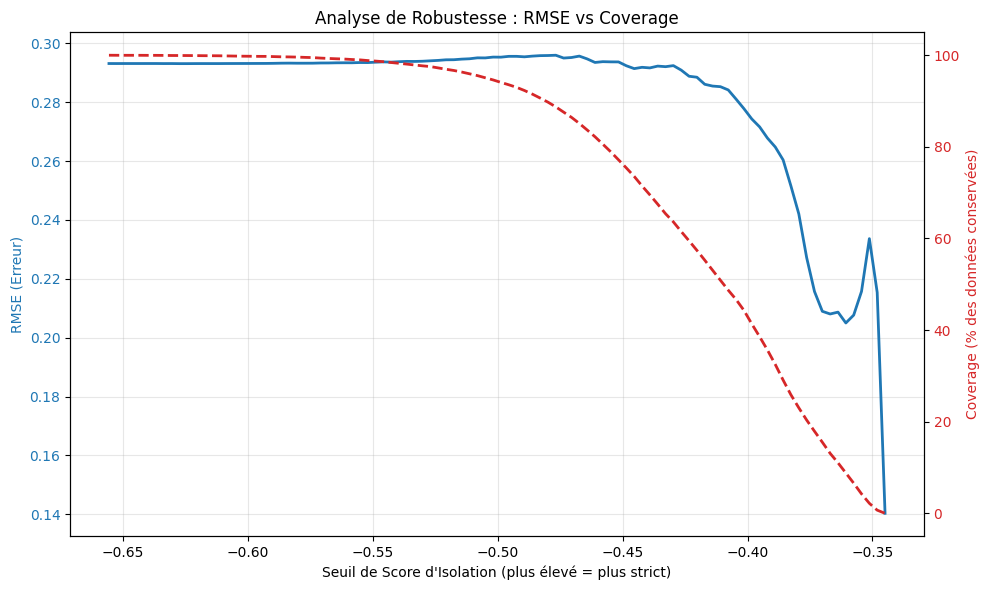

In [ ]:
iso_forest = IsolationForest(random_state=42)
iso_forest.fit(X_train_scaled)

anomaly_scores = iso_forest.score_samples(X_test_scaled)

thresholds = np.linspace(anomaly_scores.min(), anomaly_scores.max(), 100)
count, rmse = [], []
n_total = len(y_test)

for t in thresholds:
    mask = anomaly_scores >= t
    count.append(100 *mask.sum()/n_total)
    error = mean_squared_error(y_test[mask], y_pred[mask]) if mask.sum() > 0 else np.nan
    rmse.append(np.sqrt(error))

fig, ax1 = plt.subplots(figsize=(10, 6))

# ax1 : RMSE
ax1.plot(thresholds, rmse, color='tab:blue', linewidth=2, label='RMSE')
ax1.set_xlabel('Seuil de Score d\'Isolement (plus élevé = plus strict)')
ax1.set_ylabel('RMSE (Erreur)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# ax2 : Coverage
ax2 = ax1.twinx()
ax2.plot(thresholds, count, color='tab:red', linestyle='--', linewidth=2, label='Coverage %')
ax2.set_ylabel('Coverage (% des données conservées)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Titre et légende
plt.title('Analyse de Robustesse : RMSE vs Coverage')
fig.tight_layout()

## Tests d'imputation

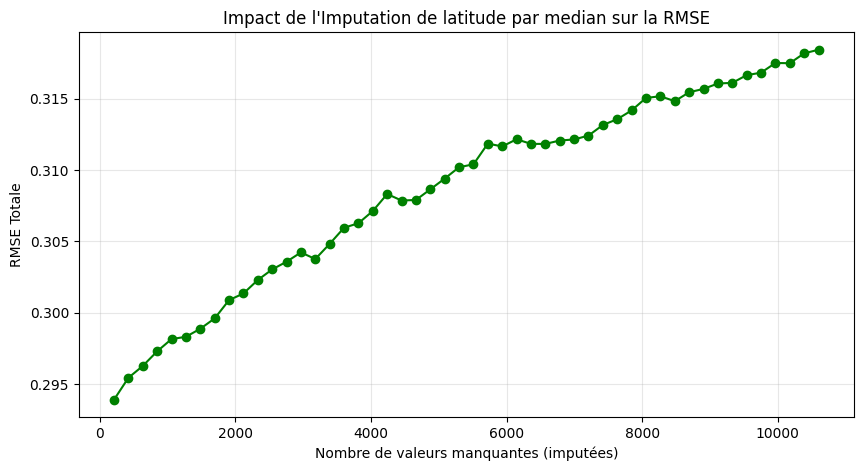

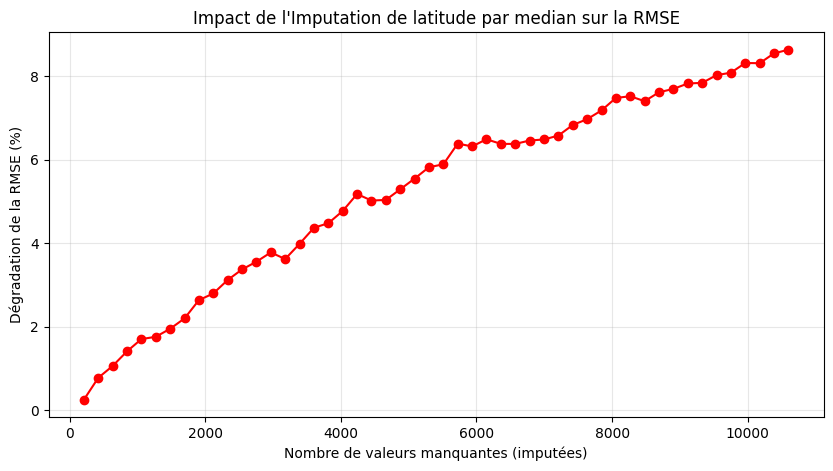

In [225]:
feature_idx = 0
range_scale = int(X_test.shape[0] / 100)
n_missing_range = range(range_scale, int(X_test.shape[0] / 2), range_scale)
rmse_imputation = []
degradation = []

for n_missing in n_missing_range:
    X_test_corrupted = X_test.copy()
    
    # Sélection aléatoire des indices à supprimer
    rmse_val = []
    for i in range(5):
        random_indices = np.random.choice(X_test_corrupted.shape[0], n_missing, replace=False)
        
        # Injection des valeurs manquantes
        X_test_corrupted.iloc[random_indices, feature_idx] = np.nan

        X_test_imputed = imputer.transform(X_test_corrupted)
        X_test_imputed = scaler.transform(X_test_imputed)
        
        # Prédiction et calcul de la RMSE
        y_pred_imputed = xgb_model.predict(X_test_imputed)
        rmse_val.append(np.sqrt(mean_squared_error(y_test, y_pred_imputed)))
    rmse_imputation.append(np.mean(rmse_val))
    degradation.append((np.mean(rmse_val) - rmse_base) / rmse_base * 100)

# Tracé de la courbe de résistance
plt.figure(figsize=(10, 5))
plt.plot(n_missing_range, rmse_imputation, marker='o', color='green', linestyle='-')
plt.xlabel('Nombre de valeurs manquantes (imputées)')
plt.ylabel('RMSE Totale')
plt.title(f'Impact de l\'Imputation de {X.columns[feature_idx]} par {strategy} sur la RMSE')
plt.grid(True, alpha=0.3)

plt.figure(figsize=(10, 5))
plt.plot(n_missing_range, degradation, marker='o', color='red', linestyle='-')
plt.xlabel('Nombre de valeurs manquantes (imputées)')
plt.ylabel('Dégradation de la RMSE (%)')
plt.title(f'Impact de l\'Imputation de {X.columns[feature_idx]} par {strategy} sur la RMSE')
plt.grid(True, alpha=0.3)

plt.show()

## Tests de bruit

In [207]:
def noise_importance(
        model,
        X_test,
        y_test,
        noise_levels,
        n_repeats=10,
        random_state=42
):
    rng = np.random.default_rng(random_state)
    n_features = X_test.shape[1]

    rmse_clean = np.sqrt(mean_squared_error(y_test, y_pred))

    results = np.zeros((n_features, len(noise_levels)))

    for j in range(n_features):
        for k, level in enumerate(noise_levels):
            rmse_runs = []

            for _ in range(n_repeats):
                X_noisy = X_test.copy()
                noise = rng.normal(
                    0,
                    level / 100,
                    size=X_test.shape[0]
                )
                X_noisy[:, j] += noise

                preds = model.predict(X_noisy)
                rmse = np.sqrt(mean_squared_error(y_test, preds))
                rmse_runs.append(rmse)

            results[j, k] = 100 * (np.mean(rmse_runs) - rmse_clean) / rmse_clean

    return results

In [208]:
noise_levels = np.array([1, 3, 5, 10, 15, 20])

# importance_matrix = noise_importance(
#     xgb_model,
#     X_test.to_numpy(),
#     y_test.to_numpy() if hasattr(y_test, "to_numpy") else y_test,
#     noise_levels,
#     n_repeats=20
# )

In [209]:
# feature_names = X_test.columns.to_list()
# global_importance = importance_matrix.mean(axis=1)
# ranking = np.argsort(global_importance)[::-1]
# import matplotlib.pyplot as plt

# top = 5
# plt.figure()

# for i in range(top):
#     idx = ranking[i]
#     plt.plot(noise_levels, importance_matrix[idx], label=feature_names[idx])

# plt.xlabel("Niveau de bruit (%)")
# plt.ylabel("Delta RMSE (%)")
# plt.title("Impact du bruit – Top features")
# plt.legend()
# plt.show()